=== Binary Classification (Classes 2 & 3) ===

Run 1
Best C: 1, Validation Error: 0.2333
Test Error: 0.1667

Run 2
Best C: 10, Validation Error: 0.2333
Test Error: 0.1333

Run 3
Best C: 0.1, Validation Error: 0.1000
Test Error: 0.1333

Run 4
Best C: 0.1, Validation Error: 0.1333
Test Error: 0.2000

Run 5
Best C: 1, Validation Error: 0.0667
Test Error: 0.2667

Run 1
Best C: 10, Validation Error: 0.2000
Test Error: 0.1000

Run 2
Best C: 100, Validation Error: 0.2000
Test Error: 0.1000

Run 3
Best C: 1, Validation Error: 0.0667
Test Error: 0.1667

Run 4
Best C: 10, Validation Error: 0.1333
Test Error: 0.2000

Run 5
Best C: 1, Validation Error: 0.1667
Test Error: 0.1667

Run 1
Best C: 1, Validation Error: 0.3000
Test Error: 0.4000

Run 2
Best C: 0.1, Validation Error: 0.4000
Test Error: 0.4667

Run 3
Best C: 0.01, Validation Error: 0.4000
Test Error: 0.4000

Run 4
Best C: 0.01, Validation Error: 0.4000
Test Error: 0.4000

Run 5
Best C: 0.01, Validation Error: 0.4000
Test Error: 0.4000

===

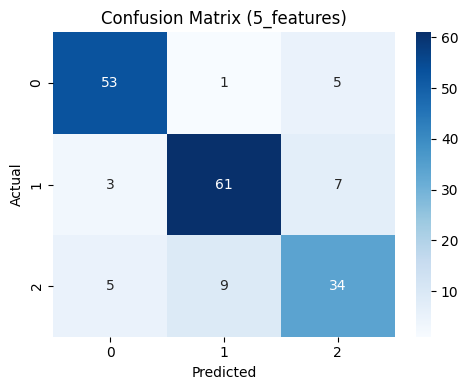


All Features -> Mean Error: 0.0394, Std: 0.0139

Classification Report (All Features):
              precision    recall  f1-score   support

           1       0.97      1.00      0.98        59
           2       0.98      0.92      0.95        71
           3       0.92      0.98      0.95        48

    accuracy                           0.96       178
   macro avg       0.96      0.96      0.96       178
weighted avg       0.96      0.96      0.96       178



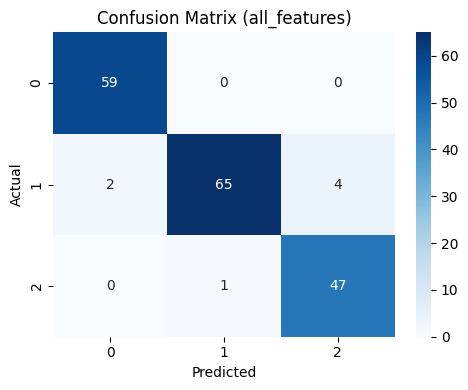

In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# -------------------------
# Paths
# -------------------------
DATA_PATH = "wine.data"
RESULTS_DIR = Path("results")

RESULTS_DIR.mkdir(exist_ok=True)

# -------------------------
# Load Data
# -------------------------
def load_data(binary=True, path=DATA_PATH):
    data = pd.read_csv(path, header=None)
    data.columns = ["class"] + [f"x{i}" for i in range(1, 14)]

    if binary:
        data = data[data["class"].isin([2, 3])]

    X = data.iloc[:, 1:].to_numpy()
    y = data["class"].to_numpy()

    return X, y

# -------------------------
# Train + Validate Model
# -------------------------
def train_validate(X, y, kernel="linear"):
    C_values = [0.01, 0.1, 1, 10, 100]
    test_errors = []

    for run in range(5):
        print(f"\nRun {run + 1}")

        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y, train_size=0.5, stratify=y, random_state=run
        )

        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=run
        )

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)
        X_test = scaler.transform(X_test)

        best_C = None
        best_val_error = 1.0

        for C in C_values:
            if kernel == "linear":
                model = SVC(kernel="linear", C=C)
            elif kernel == "rbf":
                model = SVC(kernel="rbf", C=C, gamma="scale")
            elif kernel == "poly":
                model = SVC(kernel="poly", C=C, degree=4)
            else:
                raise ValueError(f"Unsupported kernel: {kernel}")

            model.fit(X_train, y_train)
            val_pred = model.predict(X_val)

            val_error = 1 - accuracy_score(y_val, val_pred)

            if val_error < best_val_error:
                best_val_error = val_error
                best_C = C

        print(f"Best C: {best_C}, Validation Error: {best_val_error:.4f}")

        if kernel == "linear":
            final_model = SVC(kernel="linear", C=best_C)
        elif kernel == "rbf":
            final_model = SVC(kernel="rbf", C=best_C, gamma="scale")
        elif kernel == "poly":
            final_model = SVC(kernel="poly", C=best_C, degree=4)

        final_model.fit(X_train, y_train)
        test_pred = final_model.predict(X_test)

        test_error = 1 - accuracy_score(y_test, test_pred)
        test_errors.append(test_error)

        print(f"Test Error: {test_error:.4f}")

    return np.mean(test_errors), np.std(test_errors)

# -------------------------
# Cross Validation + Confusion Matrix
# -------------------------
def cross_validation(X, y):
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

    errors = []
    y_pred_total = np.zeros_like(y)

    for train_idx, test_idx in kf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = SVC(kernel="linear", C=1, decision_function_shape="ovo")
        model.fit(X_train, y_train)

        preds = model.predict(X_test)
        y_pred_total[test_idx] = preds

        error = 1 - accuracy_score(y_test, preds)
        errors.append(error)

    mean_error = np.mean(errors)
    std_error = np.std(errors)
    cm = confusion_matrix(y, y_pred_total)

    return mean_error, std_error, cm, y_pred_total

# -------------------------
# Plot Confusion Matrix
# -------------------------
def plot_confusion_matrix(cm, name):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix ({name})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"confusion_matrix_{name}.png", dpi=300)
    plt.show()

# -------------------------
# Main
# -------------------------
if __name__ == "__main__":
    print("=== Binary Classification (Classes 2 & 3) ===")
    X, y = load_data(binary=True)

    mean_lin, std_lin = train_validate(X[:, :5], y, kernel="linear")
    mean_rbf, std_rbf = train_validate(X[:, :5], y, kernel="rbf")
    mean_poly, std_poly = train_validate(X[:, :5], y, kernel="poly")

    print("\n=== Binary Classification Results ===")
    print(f"Linear: Mean Error = {mean_lin:.4f}, Std = {std_lin:.4f}")
    print(f"RBF:    Mean Error = {mean_rbf:.4f}, Std = {std_rbf:.4f}")
    print(f"Poly:   Mean Error = {mean_poly:.4f}, Std = {std_poly:.4f}")

    print("\n=== Multiclass Classification ===")
    X_all, y_all = load_data(binary=False)

    mean5, std5, cm5, y_pred_5 = cross_validation(X_all[:, :5], y_all)
    print(f"\n5 Features -> Mean Error: {mean5:.4f}, Std: {std5:.4f}")
    print("\nClassification Report (5 Features):")
    print(classification_report(y_all, y_pred_5))
    plot_confusion_matrix(cm5, "5_features")

    mean_all, std_all, cm_all, y_pred_all = cross_validation(X_all, y_all)
    print(f"\nAll Features -> Mean Error: {mean_all:.4f}, Std: {std_all:.4f}")
    print("\nClassification Report (All Features):")
    print(classification_report(y_all, y_pred_all))
    plot_confusion_matrix(cm_all, "all_features")